In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torchvision import models
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split


In [2]:

# 1. 데이터 증강 및 로드 (Validation Set 분리 포함)
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2023, 0.1994, 0.2010)),
])

# 전체 Train 데이터를 받고 Index를 나누어 Train/Val 분리
full_trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
train_idx, val_idx = train_test_split(list(range(len(full_trainset))), test_size=0.1, random_state=42)

train_loader = DataLoader(Subset(full_trainset, train_idx), batch_size=64, shuffle=True)
val_loader = DataLoader(Subset(full_trainset, val_idx), batch_size=64, shuffle=False)

testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)
test_loader = DataLoader(testset, batch_size=64, shuffle=False)


c:\Users\darwi\.conda\envs\env1\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


In [ ]:

# 2. 모델 설정 및 레이어 고정
model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)

# [레이어 고정] 특징 추출기(Features) 부분의 가중치를 고정
for param in model.features.parameters():
    param.requires_grad = False

# 분류기 재설계 (CIFAR-10 클래스 10개)
num_features = model.classifier[6].in_features
model.classifier[6] = nn.Linear(num_features, 10)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
model = model.to(device)


In [4]:

# 3. 손실 함수 및 옵티마이저
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.classifier.parameters(), lr=0.001) # 우선 분류기만 학습


In [5]:

# 4. 학습 및 검증 루프
def train_model(model, train_loader, val_loader, epochs=10):
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}
    
    for epoch in range(epochs):
        model.train()
        train_loss, train_correct = 0, 0
        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item() * inputs.size(0)
            _, preds = torch.max(outputs, 1)
            train_correct += torch.sum(preds == labels.data)
        
        # 검증 단계
        model.eval()
        val_loss, val_correct = 0, 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                _, preds = torch.max(outputs, 1)
                val_correct += torch.sum(preds == labels.data)
        
        train_loss /= len(train_idx)
        train_acc = train_correct.double() / len(train_idx)
        val_loss /= len(val_idx)
        val_acc = val_correct.double() / len(val_idx)
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc.item())
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc.item())
        
        print(f'Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} Acc: {train_acc:.4f} | Val Loss: {val_loss:.4f} Acc: {val_acc:.4f}')
    
    return history

# 학습 실행
history = train_model(model, train_loader, val_loader, epochs=10)


Epoch 1/10 | Train Loss: 0.7371 Acc: 0.7678 | Val Loss: 0.5975 Acc: 0.7846
Epoch 2/10 | Train Loss: 0.5746 Acc: 0.8273 | Val Loss: 0.4076 Acc: 0.8714
Epoch 3/10 | Train Loss: 0.5046 Acc: 0.8491 | Val Loss: 0.4047 Acc: 0.8730
Epoch 4/10 | Train Loss: 0.4599 Acc: 0.8653 | Val Loss: 0.3881 Acc: 0.8784
Epoch 5/10 | Train Loss: 0.4278 Acc: 0.8770 | Val Loss: 0.4229 Acc: 0.8626
Epoch 6/10 | Train Loss: 0.3842 Acc: 0.8884 | Val Loss: 0.4147 Acc: 0.8742
Epoch 7/10 | Train Loss: 0.3827 Acc: 0.8923 | Val Loss: 0.3866 Acc: 0.8854
Epoch 8/10 | Train Loss: 0.3798 Acc: 0.8977 | Val Loss: 0.4129 Acc: 0.8776
Epoch 9/10 | Train Loss: 0.3530 Acc: 0.9033 | Val Loss: 0.3946 Acc: 0.8750
Epoch 10/10 | Train Loss: 0.3119 Acc: 0.9124 | Val Loss: 0.3921 Acc: 0.8924


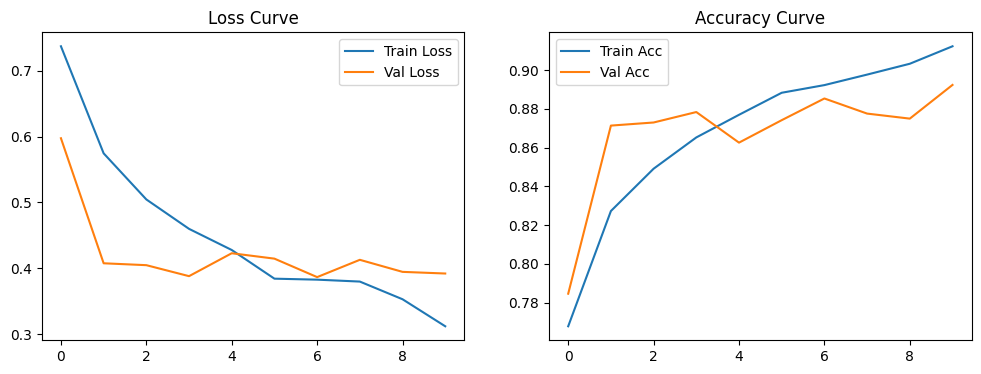

In [7]:

# 5. 결과 시각화
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.legend(); plt.title('Loss Curve')

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.legend(); plt.title('Accuracy Curve')
plt.show()